In [1]:
import os
import sys
import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt

# menambahkan module dari berbagai folder
ROOT = os.path.abspath('..')
sys.path.append(ROOT)
from preprocessing import resize_images, resize_masks, laplacian_hr, bothat_hr
from dataset import ISICDataset
from models import UNet
from torch.utils.data import DataLoader
from utils.augmentation import get_train_transforms, get_val_transforms
from utils.metrics import SegmentationMetrics

In [2]:
img_path = os.path.join(ROOT, "dataset/training/images/ISIC_0000148.jpg")
image = cv2.imread(img_path)
image_resized = cv2.resize(image, (256, 256),
                           interpolation=cv2.INTER_LANCZOS4)

/home/reva/.conda/envs/torch-pip/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1673: RuntimeWarning: invalid value encountered in divide
  res *= (1 - noise / lVar)


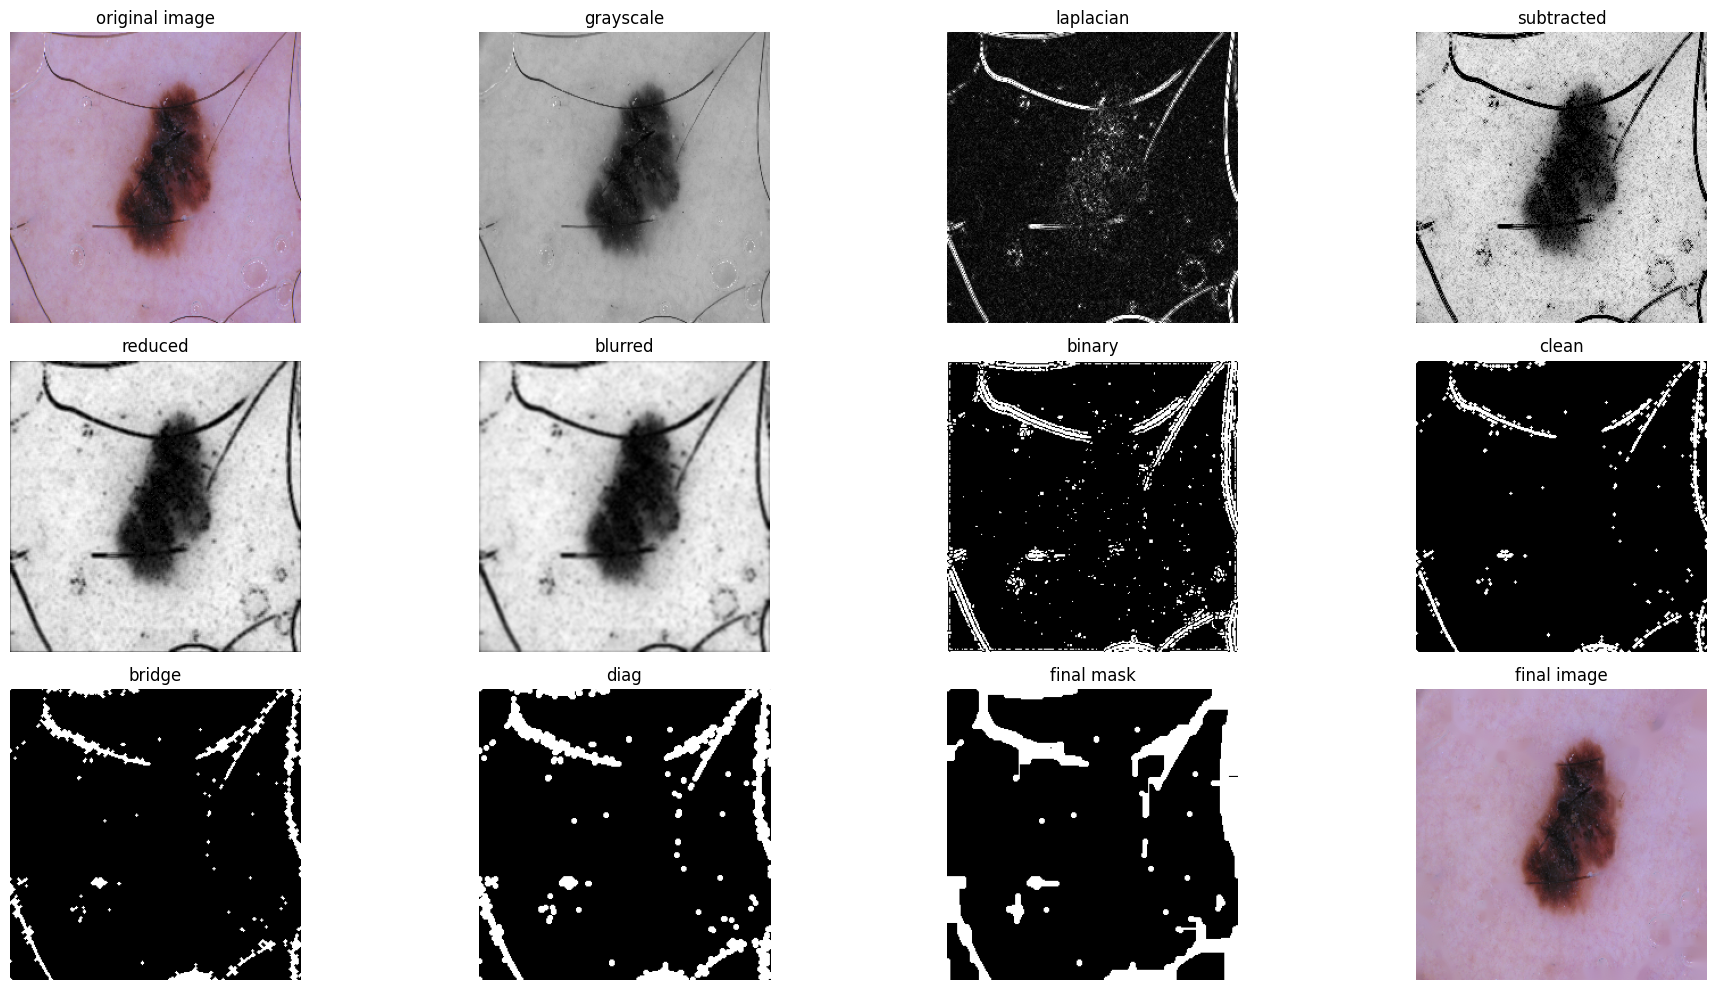

In [3]:
img_laplacian, mask_hair_l = laplacian_hr(image_resized, debug=True, save_debug=True)

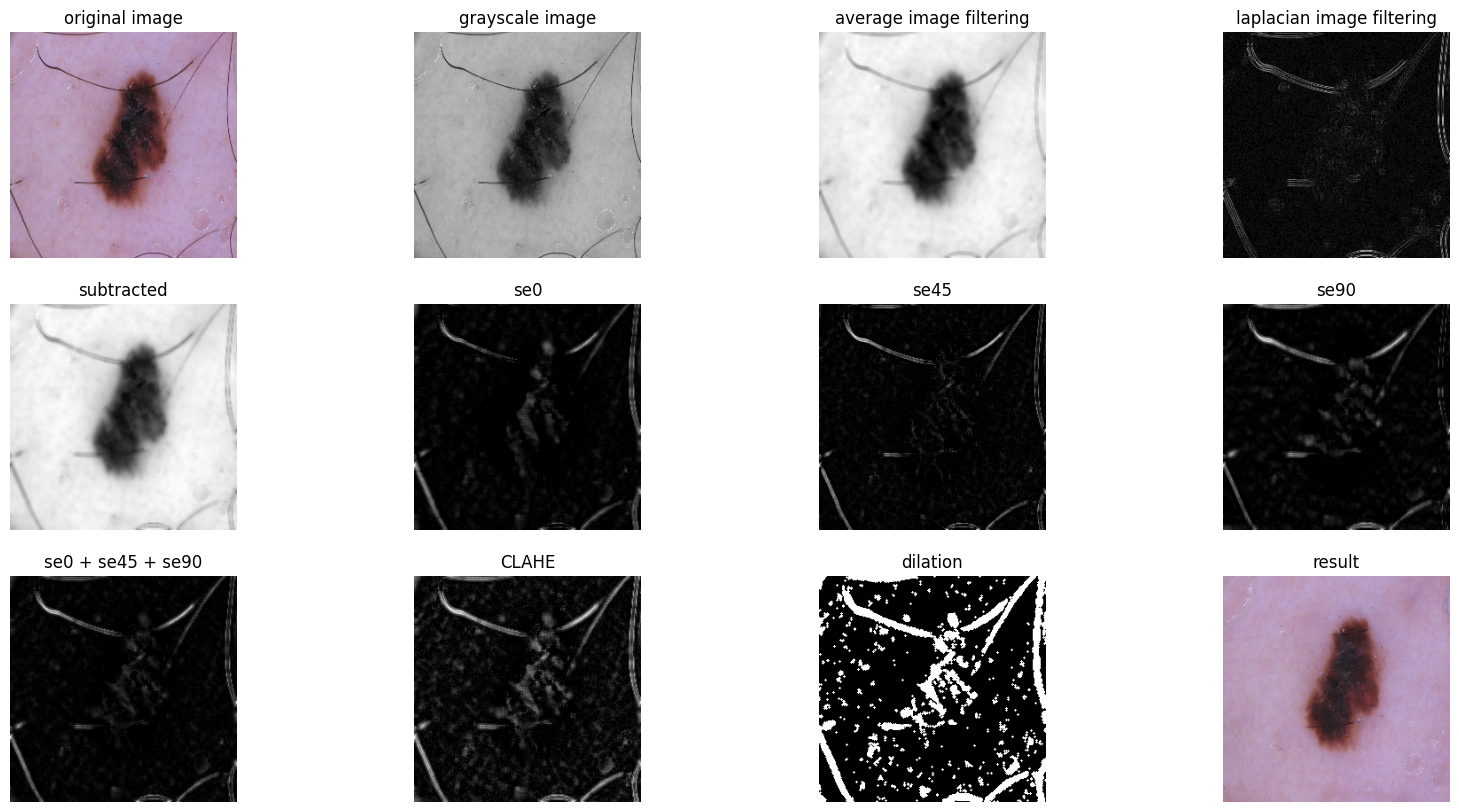

In [4]:
img_bothat, img_mask_b = bothat_hr(image_resized, debug=True, save_debug=True)

## 2. Class Activation Maps (CAM)

In [5]:
# from utils.visualization import (
#     compute_quality_distribution, plot_quality_distribution,
#     visualize_single_cam, visualize_multiple_cams
# )

# # Load best model
# model_path = os.path.join(ROOT, "checkpoints/original/best_model.pth")
# checkpoint = torch.load(model_path, map_location='cpu')
# model = UNet(in_channels=3, num_classes=1)
# model.load_state_dict(checkpoint['model_state'])

# # Setup validation datasetos.path.abspath("..")
# val_dataset = ISICDataset(
#     split='validation',
#     root_dir=os.path.join(ROOT, "dataset/resized"),
#     transform=get_val_transforms()
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=4,
#     shuffle=False,
#     num_workers=2,
#     pin_memory=True
# )

# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f"Using device: {device}")

In [6]:
# # Visualisasi Grad-CAM untuk 6 random samples
# visualize_multiple_cams(
#     model, val_dataset,
#     num_samples=6,
#     target_layer='bottleneck',
#     device=device
# )

In [7]:
# # Compute quality distribution
# quality_metrics = compute_quality_distribution(model, val_loader, device=device)

# # Plot distribution
# plot_quality_distribution(
#     quality_metrics,
#     title="Validation Set - Segmentation Quality Distribution"
# )

# Visualisasi Model Performance

## 1. Segmentation Quality Distribution